# GH200 vs DGX Spark — Attention Benchmark Analysis

Comparing scaled-dot-product attention (SDPA) performance on two GPU systems:
- **GH200 120GB** (Hopper, Alps / CSCS)
- **DGX Spark (GB10)** (Blackwell, enverge.ai)

All benchmarks use **FP16**, 64 attention heads, head dim 128.

Two attention regimes:
- **Prefill** — full causal self-attention over the whole prompt (Q = K = V length)
- **Decode** — single query token attending over an existing KV cache

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

RESULTS = Path(".")

GPU_LABELS = {
    "NVIDIA GH200 120GB": "GH200 120GB",
    "NVIDIA GB10":        "DGX Spark (GB10)",
}
PALETTE = {
    "GH200 120GB":      "#1565C0",
    "DGX Spark (GB10)": "#C62828",
}
SYSTEMS = list(PALETTE)
BATCH_MARKERS = {1: "o", 2: "s", 4: "^", 8: "D"}

def kfmt(x, _):
    return f"{int(x):,}"

def plot_lines(ax, df, x_col, y_col, label_fn=None):
    """Draw one solid line per (system, batch), colour=system, marker=batch.
    If label_fn is given, annotate each point with label_fn(y_value)."""
    batches = sorted(df["batch"].unique())
    for i, sys in enumerate(SYSTEMS):
        for b in batches:
            sdf = df[(df["system"] == sys) & (df["batch"] == b)].sort_values(x_col)
            if sdf.empty:
                continue
            ax.plot(
                sdf[x_col], sdf[y_col],
                color=PALETTE[sys], linestyle="-",
                marker=BATCH_MARKERS[b], linewidth=1.8, markersize=7,
                label=f"{sys}  B={b}",
            )
            if label_fn is not None:
                dy = 7 if i == 0 else -13
                for _, row in sdf.iterrows():
                    ax.annotate(
                        label_fn(row[y_col]),
                        xy=(row[x_col], row[y_col]),
                        xytext=(4, dy), textcoords="offset points",
                        fontsize=7, ha="left", color=PALETTE[sys],
                    )

def add_legend(ax):
    ax.legend(fontsize=9, ncol=2, framealpha=0.9,
              title="System  /  Batch", title_fontsize=9)

prefill = pd.concat([
    pd.read_csv(RESULTS / "slurm_fp16_prefill_attention_results.csv"),
    pd.read_csv(RESULTS / "spark_fp16_prefill_attention_results.csv"),
], ignore_index=True)

decode = pd.concat([
    pd.read_csv(RESULTS / "slurm_fp16_decode_attention_results.csv"),
    pd.read_csv(RESULTS / "spark_fp16_decode_attention_results.csv"),
], ignore_index=True)

for df in [prefill, decode]:
    df["system"] = df["gpu"].map(GPU_LABELS)

print(f"Prefill rows: {len(prefill)}  |  Decode rows: {len(decode)}")
display(prefill.head(3))

Prefill rows: 32  |  Decode rows: 32


,gpu,batch,seq_len,heads,head_dim,dtype,runtime_s,latency_ms,tokens_per_s,approx_tflops,max_memory_gb,max_temperature_c,max_power_w,system
0,NVIDIA GH200 120GB,1,1024,64,128,float16,0.001443,0.096188,1.064585e+07,357.215382,0.062745,26.0,97.70,GH200 120GB
1,NVIDIA GH200 120GB,1,4096,64,128,float16,0.013512,0.900817,4.546983e+06,610.285759,0.250978,27.0,112.87,GH200 120GB
2,NVIDIA GH200 120GB,1,16384,64,128,float16,0.185894,12.392911,1.322046e+06,709.768124,1.003907,27.0,134.65,GH200 120GB


## Prefill attention

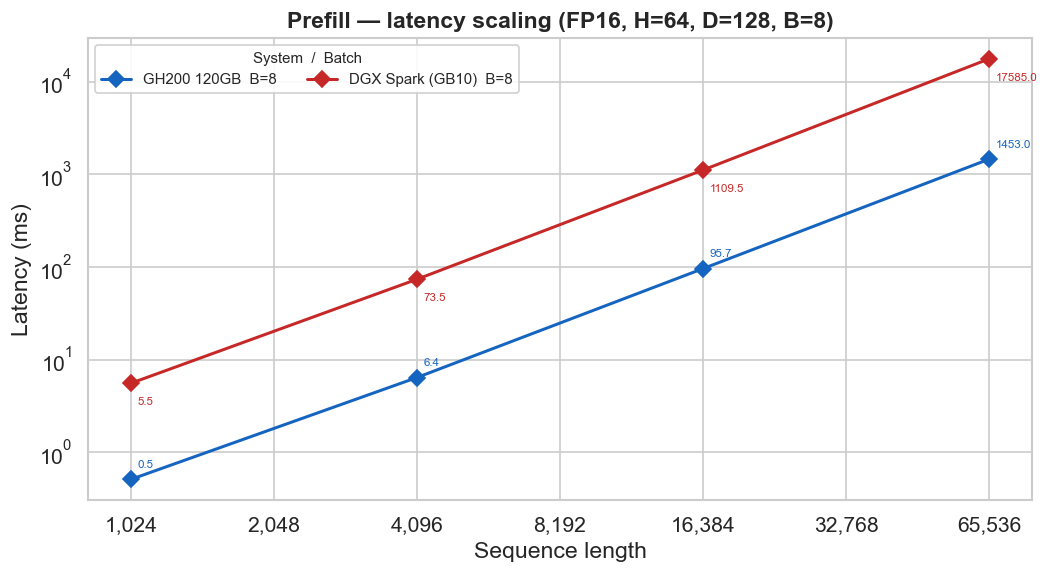

In [2]:
# Prefill: latency vs sequence length
fig, ax = plt.subplots(figsize=(9, 5))
plot_lines(ax, prefill[prefill["batch"] == 8], "seq_len", "latency_ms",
           label_fn=lambda v: f"{v:.1f}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Latency (ms)")
ax.set_title("Prefill — latency scaling (FP16, H=64, D=128, B=8)", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
add_legend(ax)
plt.tight_layout()
plt.savefig("prefill_latency_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

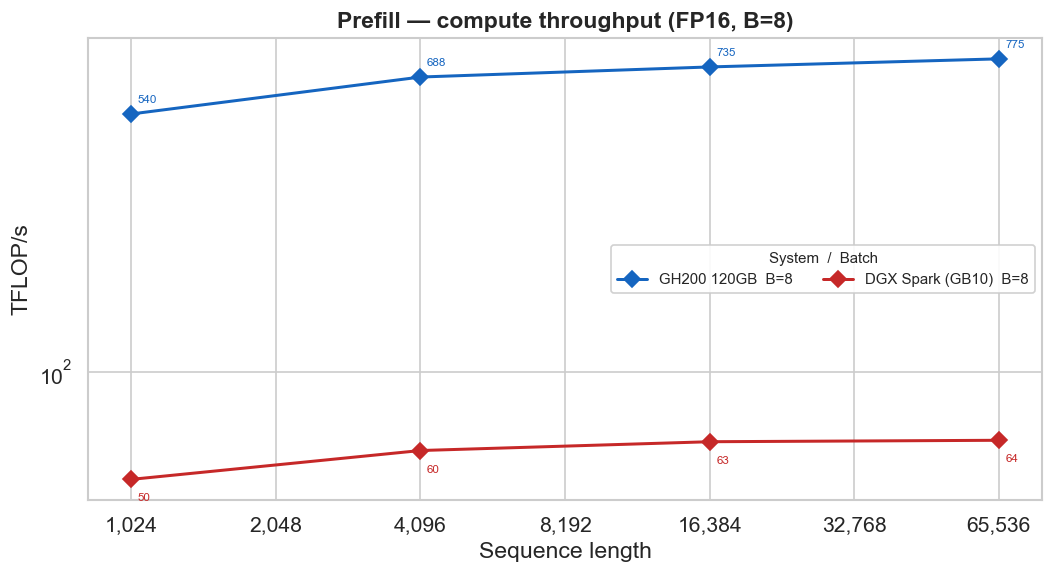

In [3]:
# Prefill: compute throughput (TFLOP/s) vs sequence length
fig, ax = plt.subplots(figsize=(9, 5))
plot_lines(ax, prefill[prefill["batch"] == 8], "seq_len", "approx_tflops",
           label_fn=lambda v: f"{v:.0f}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Sequence length")
ax.set_ylabel("TFLOP/s")
ax.set_title("Prefill — compute throughput (FP16, B=8)", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
add_legend(ax)
plt.tight_layout()
plt.savefig("prefill_tflops_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

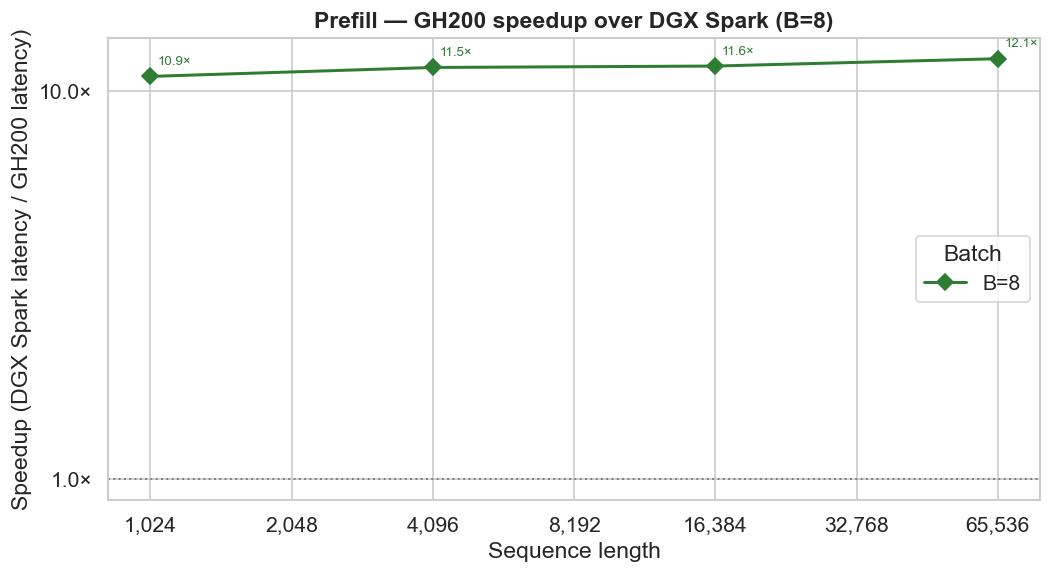

 batch  seq_len  GH200 120GB  DGX Spark (GB10)   speedup
     8     1024     0.508670          5.543554 10.898138
     8     4096     6.392233         73.450187 11.490537
     8    16384    95.745939       1109.475521 11.587703
     8    65536  1452.979818      17585.039583 12.102742


In [4]:
# Prefill: latency speedup — how many times faster is GH200 than DGX Spark?
pivot = prefill.pivot_table(
    index=["batch", "seq_len"], columns="system", values="latency_ms"
).reset_index()
pivot.columns.name = None
pivot["speedup"] = pivot["DGX Spark (GB10)"] / pivot["GH200 120GB"]
pivot = pivot[pivot["batch"] == 8]

fig, ax = plt.subplots(figsize=(9, 5))
for b, bdf in pivot.groupby("batch"):
    bdf = bdf.sort_values("seq_len")
    ax.plot(bdf["seq_len"], bdf["speedup"],
            color="#2E7D32", linestyle="-",
            marker=BATCH_MARKERS[b], linewidth=1.8, markersize=7, label=f"B={b}")
    for _, row in bdf.iterrows():
        ax.annotate(f"{row['speedup']:.1f}×",
                    xy=(row["seq_len"], row["speedup"]),
                    xytext=(4, 7), textcoords="offset points",
                    fontsize=8, color="#2E7D32", ha="left")

ax.axhline(1, color="gray", linestyle=":", linewidth=1.2)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Speedup (DGX Spark latency / GH200 latency)")
ax.set_title("Prefill — GH200 speedup over DGX Spark (B=8)", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.1f}×"))
ax.legend(title="Batch")
plt.tight_layout()
plt.savefig("prefill_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

print(pivot[["batch", "seq_len", "GH200 120GB", "DGX Spark (GB10)", "speedup"]].to_string(index=False))

## Decode attention

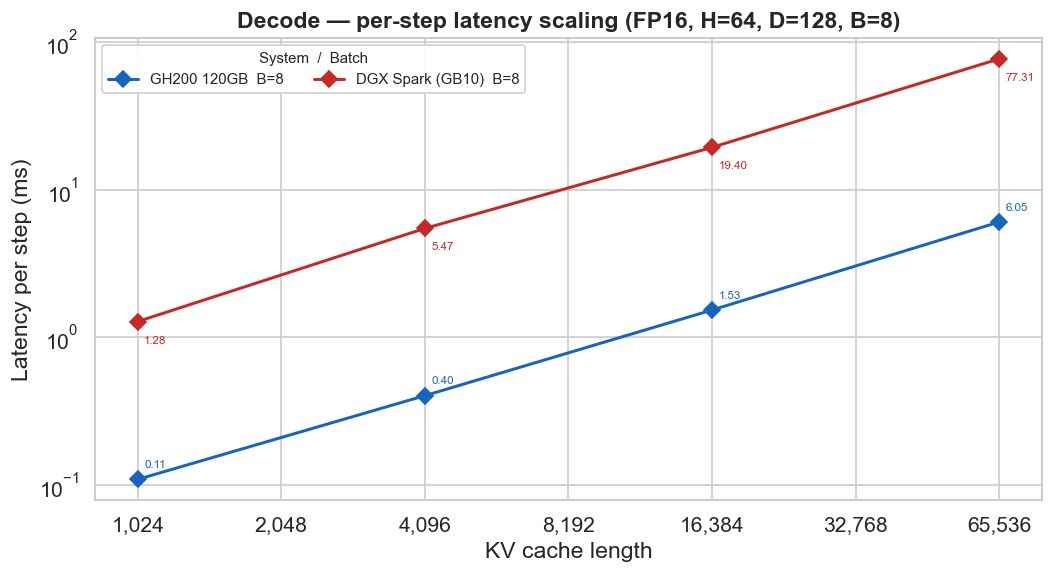

In [5]:
# Decode: per-step latency vs KV cache length
fig, ax = plt.subplots(figsize=(9, 5))
plot_lines(ax, decode[decode["batch"] == 8], "kv_len", "latency_ms",
           label_fn=lambda v: f"{v:.2f}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("KV cache length")
ax.set_ylabel("Latency per step (ms)")
ax.set_title("Decode — per-step latency scaling (FP16, H=64, D=128, B=8)", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
add_legend(ax)
plt.tight_layout()
plt.savefig("decode_latency_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

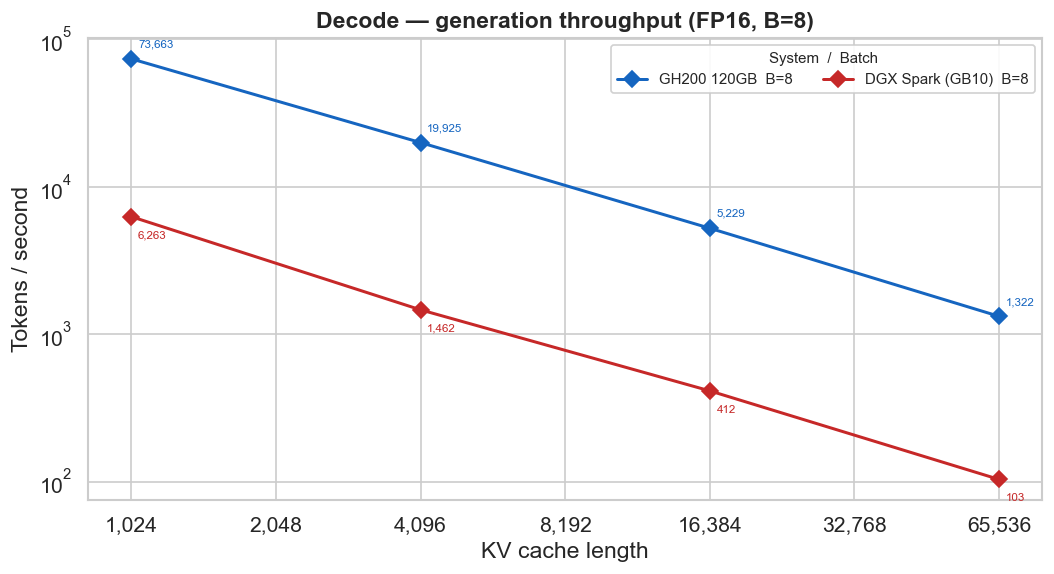

In [6]:
# Decode: generation throughput (tokens/s) vs KV cache length
fig, ax = plt.subplots(figsize=(9, 5))
plot_lines(ax, decode[decode["batch"] == 8], "kv_len", "tokens_per_s",
           label_fn=lambda v: f"{v:,.0f}")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("KV cache length")
ax.set_ylabel("Tokens / second")
ax.set_title("Decode — generation throughput (FP16, B=8)", fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
add_legend(ax)
plt.tight_layout()
plt.savefig("decode_tokens_per_s.png", dpi=150, bbox_inches="tight")
plt.show()

## Power draw

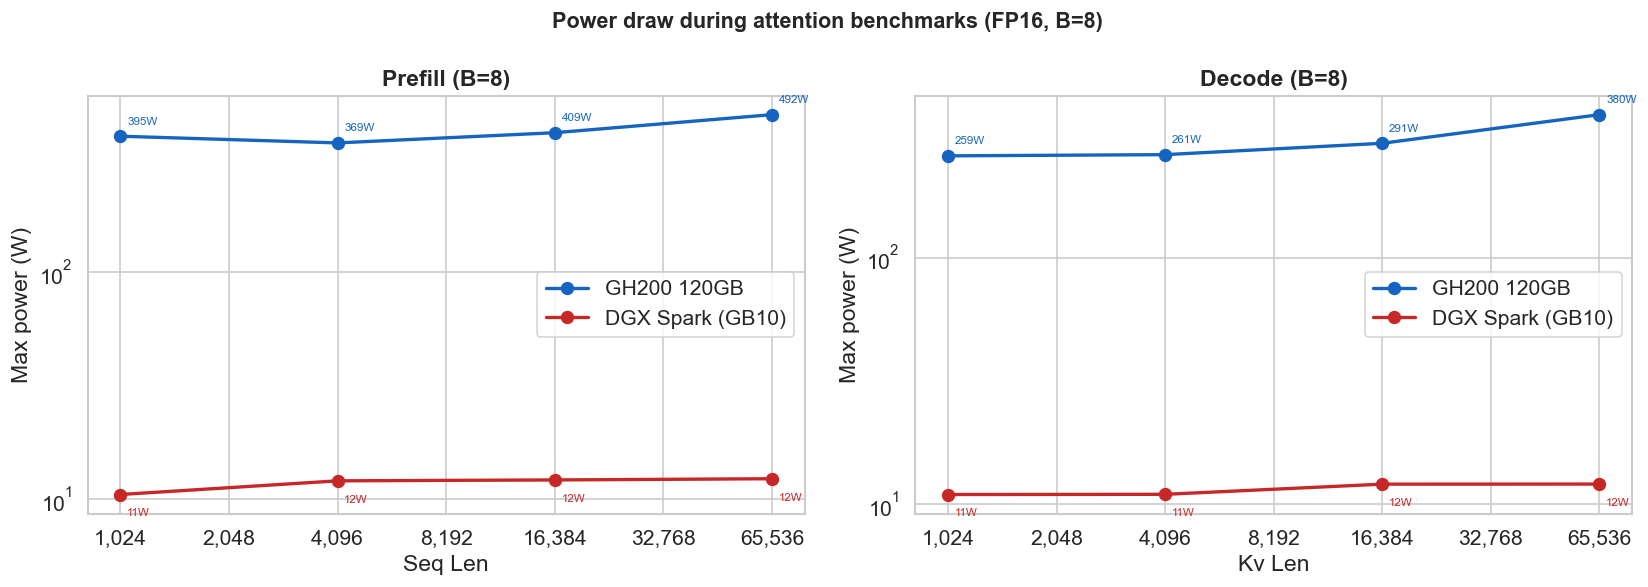

In [7]:
# Power draw during prefill and decode (B=8)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, dim_col, title in [
    (axes[0], prefill, "seq_len", "Prefill (B=8)"),
    (axes[1], decode,  "kv_len",  "Decode (B=8)"),
]:
    for i, sys in enumerate(SYSTEMS):
        sdf = df[(df["batch"] == 8) & (df["system"] == sys)].sort_values(dim_col)
        ax.plot(sdf[dim_col], sdf["max_power_w"],
                marker="o", color=PALETTE[sys], linestyle="-",
                label=sys, linewidth=2, markersize=7)
        dy = 7 if i == 0 else -13
        for _, row in sdf.iterrows():
            ax.annotate(f"{row['max_power_w']:.0f}W",
                        xy=(row[dim_col], row["max_power_w"]),
                        xytext=(4, dy), textcoords="offset points",
                        fontsize=7, ha="left", color=PALETTE[sys])
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlabel(dim_col.replace("_", " ").title())
    ax.set_ylabel("Max power (W)")
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(kfmt))
    ax.legend()

fig.suptitle("Power draw during attention benchmarks (FP16, B=8)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("power_draw.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary table

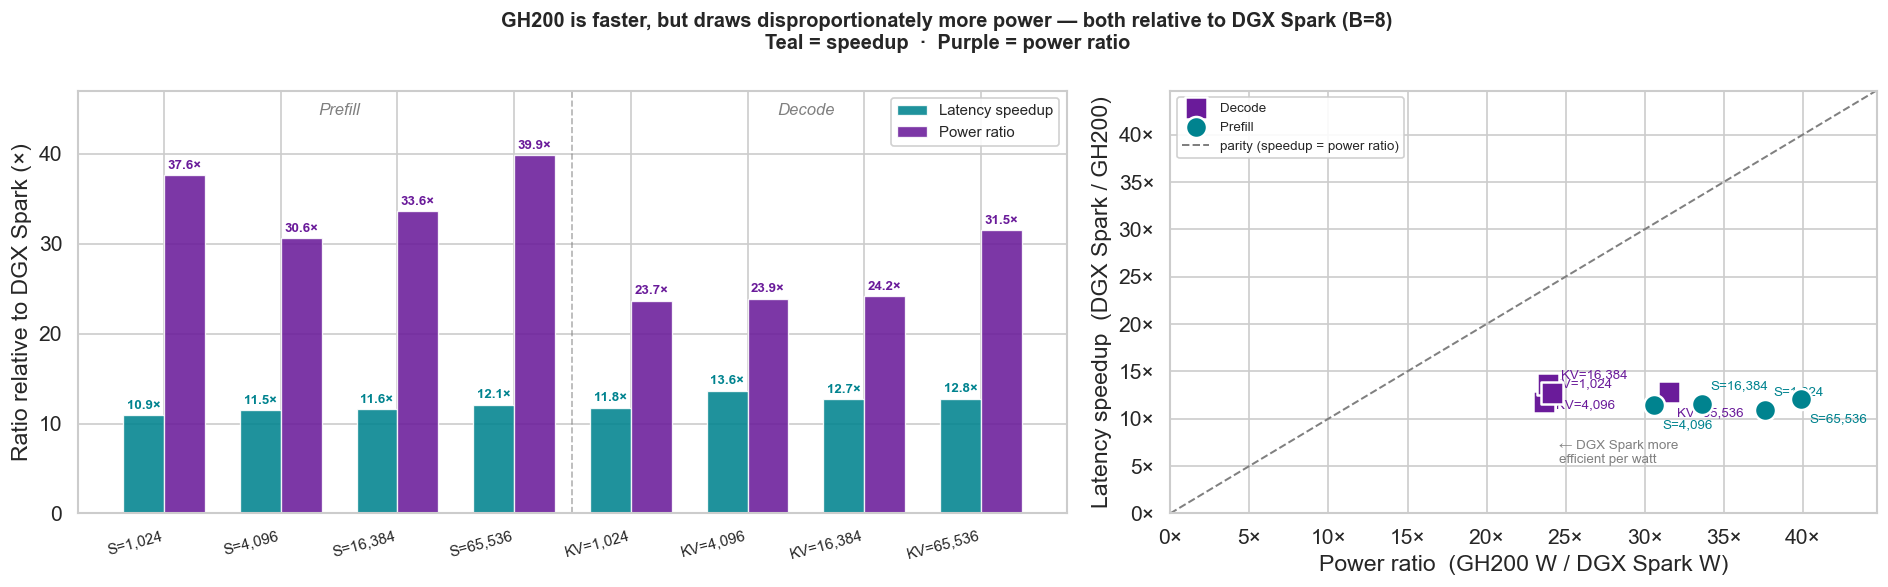

In [8]:
import numpy as np

def build_comparison(df, dim_col, regime_label, label_prefix):
    gh = df[(df["batch"] == 8) & (df["system"] == "GH200 120GB")][[dim_col, "latency_ms", "max_power_w"]]
    gb = df[(df["batch"] == 8) & (df["system"] == "DGX Spark (GB10)")][[dim_col, "latency_ms", "max_power_w"]]
    m = gh.merge(gb, on=dim_col, suffixes=("_gh", "_gb"))
    m["speedup"]     = m["latency_ms_gb"] / m["latency_ms_gh"]
    m["power_ratio"] = m["max_power_w_gh"] / m["max_power_w_gb"]
    m["regime"]      = regime_label
    m["label"]       = m[dim_col].apply(lambda x: f"{label_prefix}={x:,}")
    return m

cmp = pd.concat([
    build_comparison(prefill, "seq_len", "Prefill", "S"),
    build_comparison(decode,  "kv_len",  "Decode",  "KV"),
], ignore_index=True)

C_SPEEDUP = "#00838F"  # teal
C_POWER   = "#6A1B9A"  # purple
C_PREFILL = C_SPEEDUP
C_DECODE  = C_POWER

REGIME_MARKER = {"Prefill": "o", "Decode": "s"}
REGIME_COLOR  = {"Prefill": C_PREFILL, "Decode": C_DECODE}

OFFSETS = {
    "S=1,024":   (5,  9), "S=4,096":   (5, -14),
    "S=16,384":  (5,  9), "S=65,536":  (5, -14),
    "KV=1,024":  (5,  9), "KV=4,096":  (5, -14),
    "KV=16,384": (5,  9), "KV=65,536": (5, -14),
}

x = np.arange(len(cmp))
w = 0.35
n_prefill = (cmp["regime"] == "Prefill").sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                gridspec_kw={"width_ratios": [1.4, 1]})

# ── Left: grouped bar chart ────────────────────────────────────────────────
bars_sp = ax1.bar(x - w/2, cmp["speedup"],     w, label="Latency speedup",
                  color=C_SPEEDUP, alpha=0.88, edgecolor="white", linewidth=0.8)
bars_pr = ax1.bar(x + w/2, cmp["power_ratio"], w, label="Power ratio",
                  color=C_POWER,   alpha=0.88, edgecolor="white", linewidth=0.8)

for bars, color in [(bars_sp, C_SPEEDUP), (bars_pr, C_POWER)]:
    for b in bars:
        ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.4,
                 f"{b.get_height():.1f}×", ha="center", va="bottom",
                 fontsize=8, color=color, fontweight="bold")

ax1.axvline(n_prefill - 0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ymax = cmp[["speedup", "power_ratio"]].max().max() * 1.18
ax1.text(n_prefill / 2 - 0.5, ymax * 0.97,
         "Prefill", ha="center", va="top", fontsize=10, color="gray", fontstyle="italic")
ax1.text(n_prefill + (len(cmp) - n_prefill) / 2 - 0.5, ymax * 0.97,
         "Decode",  ha="center", va="top", fontsize=10, color="gray", fontstyle="italic")

ax1.set_xticks(x)
ax1.set_xticklabels(cmp["label"], rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Ratio relative to DGX Spark (×)")
ax1.set_ylim(0, ymax)
ax1.legend(framealpha=0.9, fontsize=9)

# ── Right: scatter with parity diagonal ───────────────────────────────────
for regime, grp in cmp.groupby("regime"):
    ax2.scatter(grp["power_ratio"], grp["speedup"],
                marker=REGIME_MARKER[regime], color=REGIME_COLOR[regime],
                s=160, zorder=4, label=regime, edgecolors="white", linewidth=1.5)

for _, row in cmp.iterrows():
    dx, dy = OFFSETS.get(row["label"], (5, 9))
    ax2.annotate(row["label"],
                 xy=(row["power_ratio"], row["speedup"]),
                 xytext=(dx, dy), textcoords="offset points",
                 fontsize=8, ha="left", color=REGIME_COLOR[row["regime"]])

lim = cmp["power_ratio"].max() * 1.12
ax2.plot([0, lim], [0, lim], color="gray", linestyle="--", linewidth=1.2,
         label="parity (speedup = power ratio)")
ax2.set_xlim(0, lim)
ax2.set_ylim(0, lim)
ax2.set_xlabel("Power ratio  (GH200 W / DGX Spark W)")
ax2.set_ylabel("Latency speedup  (DGX Spark / GH200)")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}×"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}×"))
ax2.text(lim * 0.55, lim * 0.12, "← DGX Spark more\nefficient per watt",
         fontsize=8, color="gray", ha="left")
ax2.legend(framealpha=0.9, fontsize=8)

fig.suptitle(
    "GH200 is faster, but draws disproportionately more power — both relative to DGX Spark (B=8)\n"
    "Teal = speedup  ·  Purple = power ratio",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("speedup_vs_power_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
summary_rows = []
for regime, df in [("prefill", prefill), ("decode", decode)]:
    for sys in SYSTEMS:
        sdf = df[df["system"] == sys]
        summary_rows.append({
            "Regime":           regime,
            "System":           sys,
            "Best TFLOP/s":     sdf["approx_tflops"].max(),
            "Min latency (ms)": sdf["latency_ms"].min(),
            "Max tok/s":        sdf["tokens_per_s"].max(),
            "Peak power (W)":   sdf["max_power_w"].max(),
        })

summary = pd.DataFrame(summary_rows).set_index(["Regime", "System"])
display(summary.style.format({
    "Best TFLOP/s":      "{:.1f}",
    "Min latency (ms)":  "{:.3f}",
    "Max tok/s":         "{:,.0f}",
    "Peak power (W)":    "{:.0f}",
}))